# CosMx Spatial Transcriptomics Tutorial - part 2

We are continuing with our dataset (Lung5_Rep1 public demo dataset from NanoString) and expanding more on spatial omics-specific analyses, including spatial autocorrelation, neighborhood enrichment, and co-occurrence analysis.

---

## From Part 1 (Lab): Install required packages, Download/Load dataset into AnnData format, and Preprocessing



In [ ]:
!pip install -U squidpy scanpy anndata matplotlib seaborn gdown python-igraph leidenalg --quiet
!pip install "numcodecs<0.11.0" --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.3/161.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [ ]:
import os
import tarfile

# Your shared file ID from google drive
file_id = "1ClBjGL3XANRmJteX1-bMRb3lPAmexFFG"
archive_path = "SMSS_data.tar.gz"
extract_dir = "smss_data"
os.makedirs(extract_dir, exist_ok=True)

# Download the archive
if not os.path.exists(archive_path):
    print("Downloading from Google Drive...")
    !gdown --id {file_id} -O {archive_path}
else:
    print("File already downloaded.")

# Extract the archive
print("Extracting archive...")
with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(path=extract_dir)

print("Extraction complete. Files inside:", os.listdir(extract_dir))

File already downloaded.
Extracting archive...
Extraction complete. Files inside: ['Lung5_Rep1']


In [ ]:
import squidpy as sq

adata = sq.read.nanostring(
    path="smss_data/Lung5_Rep1/Lung5_Rep1-Flat_files_and_images/",
    counts_file="Lung5_Rep1_exprMat_file.csv",
    meta_file="Lung5_Rep1_metadata_file.csv",
    fov_file="Lung5_Rep1_fov_positions_file.csv"
)

adata

/usr/lib/python3.11/importlib/__init__.py:126: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)
/usr/local/lib/python3.11/dist-packages/cudf/utils/_ptxcompiler.py:64: UserWarning: Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/cudadrv/driver.py", line 314, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA d

AnnData object with n_obs × n_vars = 100292 × 980
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_fov'

/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_normalization.py:243: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
<ipython-input-5-7a4867809736>:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


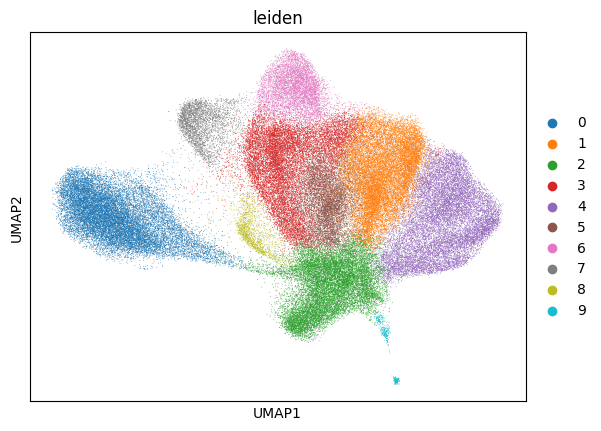

In [ ]:
import scanpy as sc

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5)
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden")
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)



## (1) Spatial autocorrlation (Moran's I):
In addition to comparing expression levels, spatial omics allows us to identify genes whose expression varies in a spatially patterned way across tissue.

We use Moran's I, the most common method to test spatial autocorrelation within a sample. Other approaches, such as Ripley’s K function, assess spatial clustering but differ in assumptions and resolution (briefly discussed below, feel free to explore on your own).

### Calculating Moran's I
For a vector of gene expression values $\mathbf{x} = [x_1, x_2, \dots, x_n]$ across $n$ spatial units (e.g., cells), Moran’s I is defined as:

$$
I = \frac{n}{W} \cdot \frac{\sum_{i=1}^n \sum_{j=1}^n w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_{i=1}^n (x_i - \bar{x})^2}
$$

Where:
- $n$: number of spatial units (cells)  
- $x_i$: gene expression in unit $i$  
- $\bar{x}$: mean expression across all units  
- $w_{ij}$: spatial weight between units $i$ and $j$ (e.g., 1 if neighbors, 0 otherwise)  
- $W = \sum_{i}\sum_{j} w_{ij}$: total sum of weights  

The spatial weights matrix $W$ defines the spatial structure:

- Often constructed using k-nearest neighbors, radius-based, or Delaunay triangulation  
- $w_{ij}$ can be binary or continuous (e.g., inverse distance)  
- The matrix can be row-normalized to adjust for variable neighborhood sizes  

Simply put, Moran's I tests whether gene expression is spatially correlated:
- **Positive** Moran's I: expression is similar in neighboring cells
- **Negative** Moran's I: dissimilarity in local expression (anti-correlation)
- **Near zero**: no spatial structure

### Comparison to Ripley’s K function
- **Ripley’s K** analyzes point pattern distributions and evaluates clustering/dispersion at varying spatial scales
- Unlike Moran’s I, it does not require expression values — typically used for cell location patterns
- Useful for assessing overall spatial density and clustering rather than value-based correlations

Therefore, you could use Moran’s I to find spatially structured genes, and Ripley’s K to analyze spatial organization of cell locations. There are other spatial autocorrelation methods that you could explore, but we are showing most common ones here.

Let's first have a toy example to see how Moran's I works by generating 10 by 10 matrix and plotting them.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
import anndata

# Create a 10x10 grid of cells with random expressions
grid_size = 10
coords = np.array([[i, j] for i in range(grid_size) for j in range(grid_size)])
expression = np.random.uniform(0, 10, size=(grid_size * grid_size))

# Create AnnData
adata = anndata.AnnData(X=expression[:, None])
adata.obsm["spatial"] = coords
adata.var_names = ["Gene1"]

# Compute spatial neighbors and Moran's I
sq.gr.spatial_neighbors(adata, coord_type="generic")
sq.gr.spatial_autocorr(adata, mode="moran")

# Visualize expression
plt.figure(figsize=(5, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=expression, cmap="coolwarm", s=100)
plt.gca().invert_yaxis()
plt.title("Simulated Expression on 10×10 Grid")
plt.colorbar(label="Gene1 Expression")
plt.axis("off")
plt.show()

# Show Moran's I score
adata.uns["moranI"]["I"]

**Question 1**:

Generate a matrix that is spatially clustered or patterned (e.g., top-left has higher values) and repeat the calculation. What moran's I value are you getting, compared to randomly generated matrix?



In [ ]:
# Spatial autocorrelation (Moran's I)
sq.gr.spatial_autocorr(adata, mode='moran')

**Question 2**:

Display moran's I calculation results (They are stored in `uns`). What are the top 3 spatially autocorrelated genes? Are the values high/low? Why do you think it's the case in this demo?  


In [ ]:
lib = "1" # FOV number
adata.uns["spatial"][lib]["images"]["segmentation"] = adata.uns["spatial"][lib]["images"]["segmentation"].copy()
sq.pl.spatial_segment(adata, color=["COL9A2"], library_id=lib, img=False, seg_cell_id="cell_ID", library_key="fov")

## (2) Neighborhood Enrichment

In spatial omics, we also often want to understand how cell types or clusters are spatially related to one another — not just their locations, but whether they physically neighbor each other more than expected by chance. Neighborhood enrichment quantifies this by comparing observed vs. expected adjacency frequencies between clusters.

### Concept

We construct a spatial neighbor graph, where:

- Nodes = cells  
- Edges = spatial proximity (e.g., defined by Delaunay triangulation or k-nearest neighbors)  
- Each node belongs to a cluster (e.g., Leiden or Louvain)

For each pair of clusters $(A, B)$, we:

1. Count how many edges exist between a cell in cluster $A$ and a cell in cluster $B$ (this is the observed count).
2. Shuffle the cluster labels multiple times (typically 100–1000 permutations).
3. For each permutation, compute the same count (this gives an expected distribution under the null of random spatial arrangement).
4. Compare the observed count to the distribution of expected counts.


### Enrichment Score

The enrichment is often reported as a z-score or ratio:

- **Z-score formulation**:
  $$
  Z_{A,B} = \frac{\text{observed}_{A,B} - \mathbb{E}[\text{random}_{A,B}]}{\text{SD}[\text{random}_{A,B}]}
  $$

- **Ratio formulation** (used in some tools):
  $$
  \text{Enrichment}_{A,B} = \frac{\text{observed}_{A,B}}{\mathbb{E}[\text{random}_{A,B}]}
  $$


### Interpretation

- A **high enrichment score** ($Z >$ 0 or ratio $>$ 1): cluster $A$ and $B$ are more likely to neighbor each other than by chance.
- A **negative score** ($Z <$ 0 or ratio $<$ 1): cluster $A$ and $B$ tend to avoid each other spatially.
- A **score near zero or 1**: spatially random relationship.

The result is often shown as a heatmap, where rows and columns are cluster IDs, and values represent enrichment strength. Neighborhood enrichment is powerful because it doesn't just assess gene expression or location, but topological proximity — key to understanding tissue architecture and cell–cell interactions.

In [ ]:
# Neighborhood enrichment between clusters
sq.gr.nhood_enrichment(adata, cluster_key='leiden')
sq.pl.nhood_enrichment(adata, cluster_key='leiden')

NameError: name 'sq' is not defined

**Question 3**:

Are there clusters that appear to physically co-localize? Any that are mutually exclusive?

## (3) Co-occurrence Analysis

While neighborhood enrichment focuses on direct adjacency between cells, co-occurrence analysis examines whether two clusters frequently appear in the same local spatial region — even if they are not touching.

This is a broader, region-level analysis that captures spatial association based on co-presence, rather than physical contact.



### Concept

- Divide the tissue into spatial bins or use local neighborhoods around each cell (e.g., radius-based).
- For each bin, identify which clusters are present (not how many cells — just presence/absence).
- Calculate how often each pair of clusters co-occur in the same bin across the entire tissue.


### Co-occurrence Score

The co-occurrence score between two clusters \( A \) and \( B \) can be defined as:

$$
\text{Cooccur}(A, B) = \frac{\text{Number of bins where both A and B are present}}{\text{Total number of bins}}
$$

To determine whether this is statistically enriched, we compare to a null distribution via permutation:

- Randomly shuffle cluster labels (preserving spatial positions)
- Recalculate co-occurrence for each permutation
- Compare observed value to the null to compute a z-score or empirical p-value


### Interpretation

- **High co-occurrence score**: clusters often inhabit the same regions, potentially interacting or sharing microenvironments
- **Low co-occurrence**: spatial segregation — these clusters tend to occur in different regions
- **Neutral** (expected by chance): no structured spatial association

This is especially useful for identifying:
- Immune cell infiltration zones (e.g., T cells + macrophages)
- Tumor–stroma regional associations
- Architectural layers (e.g., epithelial + endothelial)

---

### Comparison to Neighborhood Enrichment

| Feature                  | Neighborhood Enrichment        | Co-occurrence                     |
|--------------------------|--------------------------------|-----------------------------------|
| Unit of analysis         | **Edges between cells**        | **Presence in shared region**     |
| Captures adjacency       | ✔️ Yes                         | ❌ No                             |
| Captures co-regionality  | ❌ No                          | ✔️ Yes                            |
| Sensitive to spatial bin size | ❌ (uses graph)         | ✔️ (depends on bin/radius)        |
| Good for detecting       | **Direct contact interactions**| **Regional co-habitation**        |

---

### Biological Use Cases

- Determine whether immune and tumor cells occupy the same neighborhood
- Assess whether two stromal subtypes coexist in fibrotic zones
- Study spatial segregation in development or disease

In [ ]:
# Co-occurrence score between clusters (optional advanced)
sq.gr.co_occurrence(adata, cluster_key='leiden')
sq.pl.co_occurrence(adata, cluster_key='leiden', clusters="9")

  0%|          | 0/1225 [00:00<?, ?/s]

**Question 4**:

What other biological interpretation might you infer from the co-localization patterns? Think of examples and explain how you would investigate it.
